In [1]:
from torchvision.datasets import ImageFolder
import os
from torchvision import transforms
from torch.utils.data import dataloader, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report

In [2]:
train_transform = transforms.Compose([  # Compose allows stacking multiple transformations together


transforms.ToTensor(),  # Converts images to PyTorch tensors (from 0-255 range to 0-1 float range)

transforms.Resize((64, 64)),  # Resizes the images to 64x64 pixels

])

test_transform = transforms.Compose([  # Compose allows stacking multiple transformations together


transforms.ToTensor(),  # Converts images to PyTorch tensors (from 0-255 range to 0-1 float range)

transforms.Resize((64, 64)),  # Resizes the images to 64x64 pixels

])

In [3]:
dataset_train = ImageFolder('/kaggle/input/d/lukechugh/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset/train', 
                           transform=train_transform)

dataset_test = ImageFolder('/kaggle/input/d/lukechugh/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset/test', 
                           transform=test_transform)


In [4]:
dataloader_train = DataLoader(dataset_train,  # The training dataset loaded using ImageFolder
                          batch_size=32,  # Number of images to be passed through the network at once
                          shuffle=True  # Randomly shuffle the data at each epoch for better training
)

dataloader_test = DataLoader(dataset_test,  # The test dataset loaded using ImageFolder
                         batch_size=32,  # The same batch size as training to ensure consistency
                         shuffle=True  # Optionally shuffle test data (can be False, but True here for demonstration)
)

In [5]:
images, labels = next(iter(dataloader_train))
print(images.shape)
len(dataloader_train)


torch.Size([32, 3, 64, 64])


320

In [6]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(2704, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 4)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


net = Net()

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.001)

In [8]:
n_epoch = 10
acc_loss = []

for epoch in range(n_epoch):  # loop over the dataset multiple times

    running_loss = 0.0
    for i, data in enumerate(dataloader_train, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i % 200 == 199:    # print every 200 mini-batches
            avg_running_loss = running_loss / 200
            acc_loss.append(avg_running_loss)
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {avg_running_loss:.3f}')
            running_loss = 0.0

print('Finished Training')

[1,   200] loss: 1.001
[2,   200] loss: 0.516
[3,   200] loss: 0.376
[4,   200] loss: 0.300
[5,   200] loss: 0.226
[6,   200] loss: 0.164
[7,   200] loss: 0.116
[8,   200] loss: 0.090
[9,   200] loss: 0.085
[10,   200] loss: 0.043
Finished Training


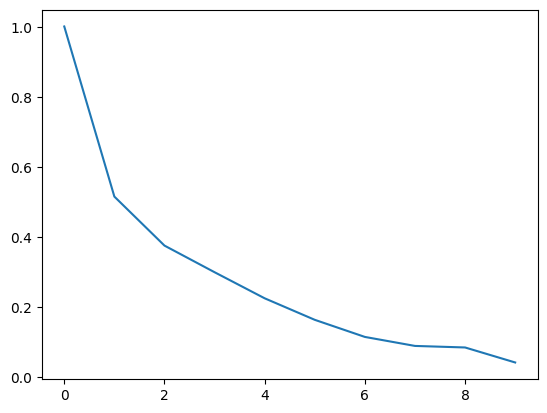

In [9]:
plt.plot(acc_loss)

In [10]:
PATH = './cifar_net.pth'
torch.save(net.state_dict(), PATH)

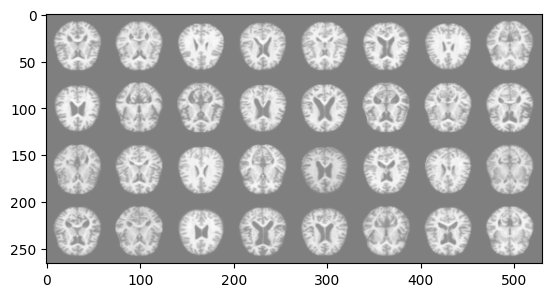

GroundTruth:  No Impairment No Impairment No Impairment Very Mild Impairment


In [11]:
dataiter = iter(dataloader_test)
images, labels = next(dataiter)

def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

classes = ('Mild Impairment', 'Moderate Impairment', 'No Impairment', 'Very Mild Impairment')

# print images
imshow(torchvision.utils.make_grid(images))
print('GroundTruth: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))

In [12]:
net = Net()
net.load_state_dict(torch.load(PATH, weights_only=True))

<All keys matched successfully>

In [13]:
outputs = net(images)

_, predicted = torch.max(outputs, 1)

print('Predicted: ', ' '.join(f'{classes[predicted[j]]:5s}'
                              for j in range(4)))

Predicted:  No Impairment No Impairment No Impairment Very Mild Impairment


In [14]:
correct = 0
total = 0
# since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad():
    for data in dataloader_test:
        images, labels = data
        # calculate outputs by running images through the network
        outputs = net(images)
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the 10000 test images: {100 * correct // total} %')

Accuracy of the network on the 10000 test images: 90 %


In [15]:
# prepare to count predictions for each class
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

# again no gradients needed
with torch.no_grad():
    for data in dataloader_test:
        images, labels = data
        outputs = net(images)
        _, predictions = torch.max(outputs, 1)
        # collect the correct predictions for each class
        for label, prediction in zip(labels, predictions):
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1


# print accuracy for each class
for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

Accuracy for class: Mild Impairment is 90.5 %
Accuracy for class: Moderate Impairment is 75.0 %
Accuracy for class: No Impairment is 95.6 %
Accuracy for class: Very Mild Impairment is 82.6 %


In [16]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# Assuming that we are on a CUDA machine, this should print a CUDA device:

print(device)

net.to(device)

inputs, labels = data[0].to(device), data[1].to(device)


cuda:0


In [17]:
y_true = []
y_pred = []

net.eval()
with torch.no_grad():
    for inputs, labels in dataloader_test:  # or val_loader
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = net(inputs)
        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

In [18]:
print(classification_report(y_true, y_pred, target_names=classes))

                      precision    recall  f1-score   support

     Mild Impairment       0.86      0.91      0.88       179
 Moderate Impairment       1.00      0.75      0.86        12
       No Impairment       0.90      0.96      0.93       640
Very Mild Impairment       0.92      0.83      0.87       448

            accuracy                           0.90      1279
           macro avg       0.92      0.86      0.88      1279
        weighted avg       0.90      0.90      0.90      1279

